# D-Wave i Ocean SDK

**D-Wave Systems** je kompanija koja proizvodi komercijalne kvantne računare bazirane na **kvantnom žarenju (Quantum Annealing)**. Njihova mašina **D-Wave Advantage** ima više od 5000 qubita međusobno povezanih u topologiji **Pegasus**.

**Ocean SDK** je D-Wave-ov open-source Python paket koji omogućava:
- Formulisanje QUBO i Izing problema
- Slanje problema na D-Wave hardver (ili simulatore)
- Analizu rezultata

---

> **Napomena:** U ovom notebooku koristimo **SimulatedAnnealingSampler** — klasični simulator koji ne zahteva D-Wave nalog. Za stvarni kvantni hardver, zameniti sa `DWaveSampler` i dodati API ključ.

## 1. Instalacija i arhitektura Ocean SDK

```bash
pip install dwave-ocean-sdk
```

### Glavni paketi

| Paket | Opis |
|---|---|
| `dimod` | Definisanje QUBO/BQM modela, sampleri |
| `dwave-neal` | Klasični SimulatedAnnealing sampler |
| `dwave-system` | Konekcija na D-Wave hardver |
| `dwave-networkx` | Graf algoritmi za D-Wave |
| `dwavebinarycsp` | Konverzija constraint satisfaction problema |
| `greedy` | SteepestDescentSampler (lokalna pretraga) |

### Centralni koncept: BQM

Ocean SDK koristi **Binary Quadratic Model (BQM)** kao centralni objekat:

$$\text{BQM} = \sum_i a_i x_i + \sum_{i<j} b_{ij} x_i x_j + c$$

BQM može biti u QUBO formi ($x_i \in \{0,1\}$) ili Izing formi ($s_i \in \{-1,+1\}$). Ocean automatski konvertuje između njih.

In [3]:
# Provera instalacije
import dimod
import neal
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
from collections import Counter

print(f"dimod verzija : {dimod.__version__}")
print(f"neal verzija  : {neal.__version__}")
print()

# Demonstracija BQM objekta
bqm = dimod.BinaryQuadraticModel(
    {'x1': -1, 'x2': -1},         # linearni koeficijenti (bias)
    {('x1','x2'): 2},              # kvadratni koeficijenti (coupling)
    0.0,                           # konstantni offset
    vartype='BINARY'               # QUBO forma
)

print("BQM objekat:")
print(f"  Promenljive  : {list(bqm.variables)}")
print(f"  Linearni     : {dict(bqm.linear)}")
print(f"  Kvadratni    : {dict(bqm.quadratic)}")
print(f"  Vartype      : {bqm.vartype}")
print()

# Ručno vredovanje
import itertools
print(f"{'x1':>4} {'x2':>4} | {'f(x)':>6}")
print("-" * 20)
for x1, x2 in itertools.product([0,1], repeat=2):
    val = bqm.energy({'x1': x1, 'x2': x2})
    print(f"{x1:>4} {x2:>4} | {val:>6.1f}")

dimod verzija : 0.12.21
neal verzija  : 0.6.0

BQM objekat:
  Promenljive  : ['x1', 'x2']
  Linearni     : {'x1': np.float64(-1.0), 'x2': np.float64(-1.0)}
  Kvadratni    : {('x2', 'x1'): np.float64(2.0)}
  Vartype      : Vartype.BINARY

  x1   x2 |   f(x)
--------------------
   0    0 |    0.0
   0    1 |   -1.0
   1    0 |   -1.0
   1    1 |    0.0


## 2. Sampleri u Ocean SDK

Ocean koristi **sampler** apstrakciju — svaki sampler prima BQM i vraća `SampleSet` sa rešenjima.

```
BQM  →  Sampler  →  SampleSet
```

### Dostupni sampleri

| Sampler | Paket | Opis |
|---|---|---|
| `SimulatedAnnealingSampler` | `neal` | Klasično simulirano žarenje |
| `SteepestDescentSampler` | `greedy` | Lokalna pretraga (brzo, ne garantuje optimum) |
| `ExactSolver` | `dimod` | Brute-force (samo mali problemi, n≤20) |
| `DWaveSampler` | `dwave-system` | Stvarni D-Wave kvantni hardver |
| `LeapHybridSampler` | `dwave-system` | D-Wave hibridni solver (kvantno + klasično) |
| `TabuSampler` | `tabu` | Tabu pretraga |

In [4]:
# Poređenje samplera na istom problemu
import dimod
import neal

# Jednostavan BQM: f = -3x1 - 5x2 - 2x3 + 4x1x2 + 2x1x3 + 3x2x3
bqm_demo = dimod.BinaryQuadraticModel(
    {'x1': -3, 'x2': -5, 'x3': -2},
    {('x1','x2'): 4, ('x1','x3'): 2, ('x2','x3'): 3},
    0.0, vartype='BINARY'
)

# Brute-force (egzaktno)
exact = dimod.ExactSolver()
exact_ss = exact.sample(bqm_demo)
best_exact = exact_ss.first

# Simulirano žarenje
sa = neal.SimulatedAnnealingSampler()
sa_ss = sa.sample(bqm_demo, num_reads=100, num_sweeps=1000)
best_sa = sa_ss.first

print("ExactSolver (brute-force):")
print(f"  Rešenje  : {dict(best_exact.sample)}")
print(f"  Energija : {best_exact.energy:.2f}")
print()
print("SimulatedAnnealingSampler:")
print(f"  Rešenje  : {dict(best_sa.sample)}")
print(f"  Energija : {best_sa.energy:.2f}")
print(f"  Pronašao optimum: {'DA ✓' if best_sa.energy == best_exact.energy else 'NE ✗'}")
print()

# SampleSet sadrži više čitanja
print(f"SA vratio {len(sa_ss)} jedinstvenih rešenja od 100 pokušaja")
print("\nTop 5 rešenja:")
print(f"{'Rešenje':>30} | {'Energija':>10} | {'Broj pojava':>12}")
print("-" * 60)
for sample, energy, num_occ in sa_ss.data(['sample','energy','num_occurrences']):
    print(f"{str(dict(sample)):>30} | {energy:>10.2f} | {num_occ:>12}")
    if energy > best_sa.energy + 2:
        break

ExactSolver (brute-force):
  Rešenje  : {'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)}
  Energija : -5.00

SimulatedAnnealingSampler:
  Rešenje  : {'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)}
  Energija : -5.00
  Pronašao optimum: DA ✓

SA vratio 100 jedinstvenih rešenja od 100 pokušaja

Top 5 rešenja:
                       Rešenje |   Energija |  Broj pojava
------------------------------------------------------------
{'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)} |      -5.00 |            1
{'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)} |      -5.00 |            1
{'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)} |      -5.00 |            1
{'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)} |      -5.00 |            1
{'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)} |      -5.00 |            1
{'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)} |      -5.00 |            1
{'x1': np.int8(0), 'x2': np.int8(1), 'x3': np.int8(0)} |    

---
## Primer 1: Max-Cut sa Ocean SDK

### Problem

Pronaći maksimalni rez grafa — particiju čvorova na $S$ i $\bar{S}$ koja maksimizuje broj grana između particija.

### Ocean pristup

Ocean SDK ima `dwave_networkx.maximum_cut` koji automatski gradi BQM, ali ovde ćemo to uraditi ručno da vidimo sve korake:

$$Q_{ii} = -\deg(i), \qquad Q_{ij} = 2 \text{ za } (i,j)\in E$$

BQM ima 6 promenljivih i 9 interakcija

Max-Cut = 7 grana
S  = [1, 2, 5]
S̄ = [0, 3, 4]
SA pronašla optimum: DA ✓


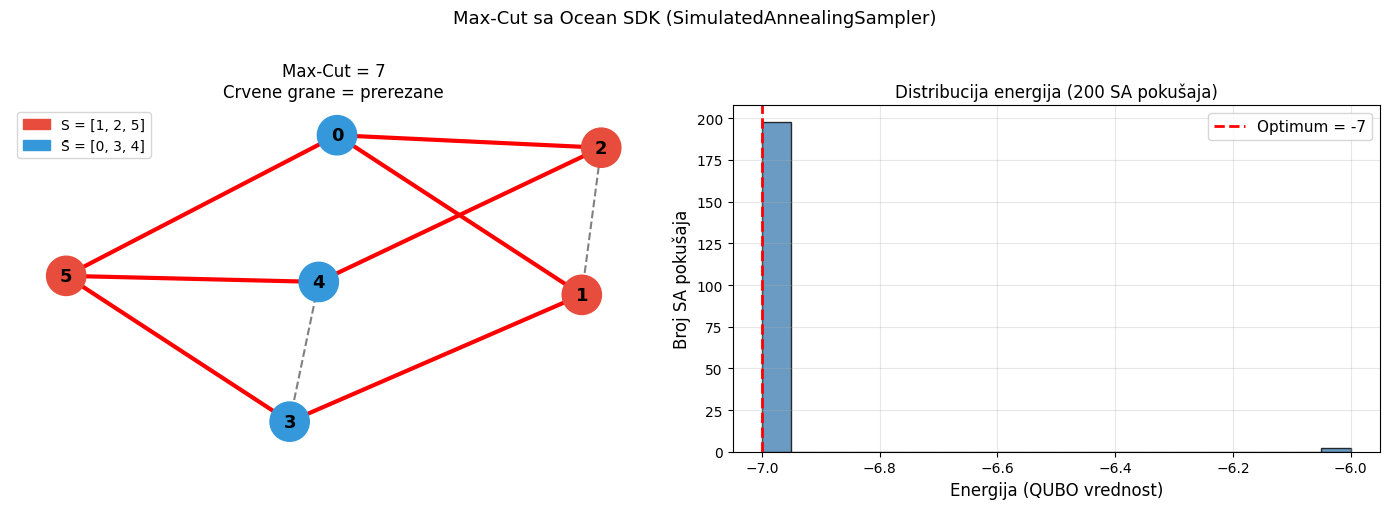

In [6]:
import dimod
import neal
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- Definisanje grafa ----
G = nx.Graph()
G.add_edges_from([
    (0,1),(0,2),(1,2),(1,3),(2,4),(3,4),(3,5),(4,5),(0,5)
])
n = G.number_of_nodes()

# ---- Gradnja BQM za Max-Cut ----
# f(x) = sum_{(i,j) in E} (-xi - xj + 2*xi*xj)  [minimizujemo]
linear = {}
quadratic = {}

for (i, j) in G.edges():
    linear[i]   = linear.get(i, 0) - 1
    linear[j]   = linear.get(j, 0) - 1
    quadratic[(i, j)] = 2

bqm = dimod.BinaryQuadraticModel(linear, quadratic, 0.0, vartype='BINARY')
print(f"BQM ima {len(bqm.variables)} promenljivih i {len(bqm.quadratic)} interakcija")

# ---- Rešavanje ----
# Egzaktno
exact_ss = dimod.ExactSolver().sample(bqm)
best_exact = exact_ss.first

# SA sa više pokušaja
sa = neal.SimulatedAnnealingSampler()
sa_ss = sa.sample(bqm, num_reads=200, num_sweeps=2000)
best_sa = sa_ss.first

cut_size = -int(best_exact.energy)
S     = {v for v, val in best_exact.sample.items() if val == 1}
S_bar = set(range(n)) - S

print(f"\nMax-Cut = {cut_size} grana")
print(f"S  = {sorted(S)}")
print(f"S̄ = {sorted(S_bar)}")
print(f"SA pronašla optimum: {'DA ✓' if best_sa.energy == best_exact.energy else 'NE ✗'}")

# ---- Vizualizacija ----
cut_edges   = [(i,j) for i,j in G.edges() if (i in S) != (j in S)]
intra_edges = [(i,j) for i,j in G.edges() if (i in S) == (j in S)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos = nx.spring_layout(G, seed=3)
node_colors = ['#E74C3C' if v in S else '#3498DB' for v in range(n)]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, ax=axes[0])
nx.draw_networkx_labels(G, pos, font_size=13, font_weight='bold', ax=axes[0])
nx.draw_networkx_edges(G, pos, edgelist=cut_edges,
                       edge_color='red', width=3, ax=axes[0])
nx.draw_networkx_edges(G, pos, edgelist=intra_edges,
                       edge_color='gray', width=1.5, style='dashed', ax=axes[0])
axes[0].set_title(f'Max-Cut = {cut_size}\nCrvene grane = prerezane', fontsize=12)
axes[0].axis('off')
p1 = mpatches.Patch(color='#E74C3C', label=f'S = {sorted(S)}')
p2 = mpatches.Patch(color='#3498DB', label=f'S̄ = {sorted(S_bar)}')
axes[0].legend(handles=[p1, p2], fontsize=10)

# Energetska distribucija SA rešenja
energies = [e for e in sa_ss.record.energy]
axes[1].hist(energies, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(best_exact.energy, color='red', linestyle='--', linewidth=2,
                label=f'Optimum = {int(best_exact.energy)}')
axes[1].set_xlabel('Energija (QUBO vrednost)', fontsize=12)
axes[1].set_ylabel('Broj SA pokušaja', fontsize=12)
axes[1].set_title('Distribucija energija (200 SA pokušaja)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Max-Cut sa Ocean SDK (SimulatedAnnealingSampler)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Primer 2: Problem ranca (Knapsack) sa Ocean SDK

### Problem

Izabrati predmete maksimalne vrednosti uz ograničenje kapaciteta ranca.

### Ocean pristup

Koristimo `dimod.BinaryQuadraticModel` sa ručno konstruisanim QUBO, ali ovog puta koristimo i `dimod.ConstrainedQuadraticModel (CQM)` — moderniji Ocean API koji direktno prima funkciju cilja i ograničenja bez ručnog izračunavanja kazni.

     Predmet | Vrednost | Težina
--------------------------------
      Laptop |       10 |      5
      Knjiga |        3 |      1
      Kamera |        7 |      4
   Slušalice |        4 |      2
      Tablet |        8 |      6
      Punjač |        2 |      1

Kapacitet ranca: W = 9

REŠENJE (Ocean SA):
  ✓       Laptop (vrednost=10, težina=5)
  ✓       Knjiga (vrednost=3, težina=1)
  ✓    Slušalice (vrednost=4, težina=2)
  ✓       Punjač (vrednost=2, težina=1)
---------------------------------------------
  Ukupna vrednost : 19
  Ukupna težina   : 9 / 9
  Ograničenje     : ZADOVOLJENO ✓


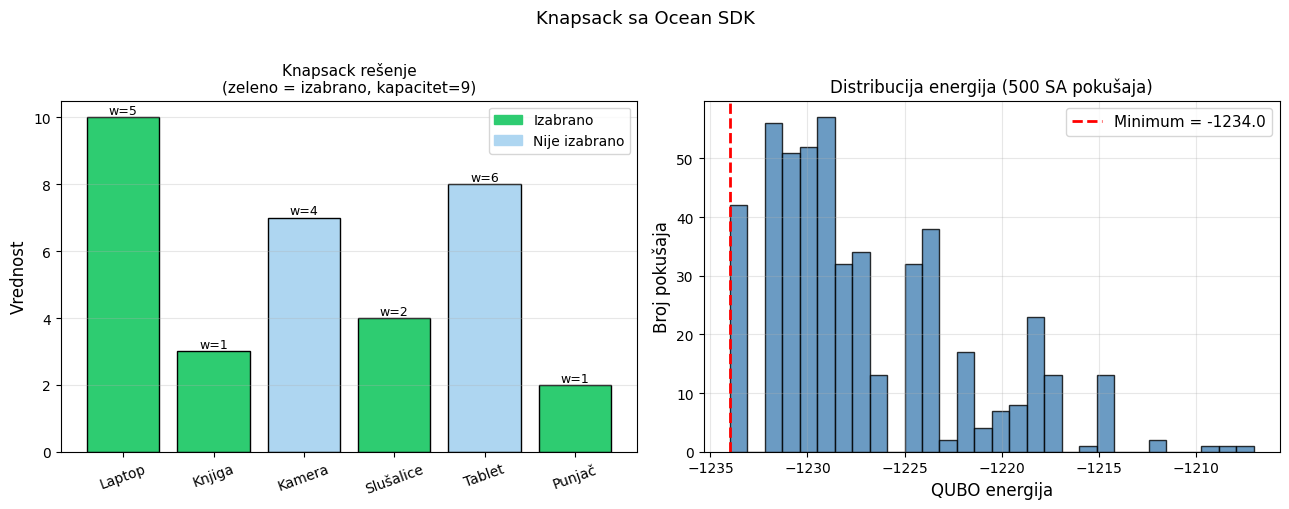

In [7]:
import dimod
import neal
import numpy as np

# ---- Podaci problema ----
items   = ['Laptop', 'Knjiga', 'Kamera', 'Slušalice', 'Tablet', 'Punjač']
values  = [10, 3, 7, 4, 8, 2]
weights = [ 5, 1, 4, 2, 6, 1]
W = 9   # kapacitet ranca

n = len(items)
print(f"{'Predmet':>12} | {'Vrednost':>8} | {'Težina':>6}")
print("-" * 32)
for name, v, w in zip(items, values, weights):
    print(f"{name:>12} | {v:>8} | {w:>6}")
print(f"\nKapacitet ranca: W = {W}")

# ======================================================
# Pristup A: Ručni QUBO + SimulatedAnnealingSampler
# ======================================================
P = 15  # kazna
n_slack = int(np.floor(np.log2(W))) + 1
slack_coeffs = [2**j for j in range(n_slack)]
var_names = items + [f's{j}' for j in range(n_slack)]
n_total = n + n_slack
c_vec = np.array(weights + slack_coeffs, dtype=float)

linear_bqm  = {}
quadratic_bqm = {}

# Cilj: -vi * xi
for i, v in enumerate(values):
    linear_bqm[var_names[i]] = linear_bqm.get(var_names[i], 0) - v

# Kazna za kapacitet
for i in range(n_total):
    linear_bqm[var_names[i]] = linear_bqm.get(var_names[i], 0) + P * (c_vec[i]**2 - 2*W*c_vec[i])
for i in range(n_total):
    for j in range(i+1, n_total):
        key = (var_names[i], var_names[j])
        quadratic_bqm[key] = quadratic_bqm.get(key, 0) + 2*P*c_vec[i]*c_vec[j]

bqm = dimod.BinaryQuadraticModel(linear_bqm, quadratic_bqm, 0.0, vartype='BINARY')

sa = neal.SimulatedAnnealingSampler()
ss = sa.sample(bqm, num_reads=500, num_sweeps=3000)

# Pronalaženje najboljeg validnog rešenja
best_valid = None
best_value = -1
for sample, energy, num_occ in ss.data(['sample','energy','num_occurrences']):
    x = [sample[items[i]] for i in range(n)]
    total_w = sum(w*xi for w, xi in zip(weights, x))
    total_v = sum(v*xi for v, xi in zip(values, x))
    if total_w <= W and total_v > best_value:
        best_value = total_v
        best_valid = x

print("\n" + "="*45)
print("REŠENJE (Ocean SA):")
print("="*45)
total_w = 0
for i, (name, v, w) in enumerate(zip(items, values, weights)):
    chosen = best_valid[i] if best_valid else 0
    if chosen:
        print(f"  ✓ {name:>12} (vrednost={v}, težina={w})")
        total_w += w
print("-" * 45)
print(f"  Ukupna vrednost : {best_value}")
print(f"  Ukupna težina   : {total_w} / {W}")
print(f"  Ograničenje     : {'ZADOVOLJENO ✓' if total_w <= W else 'NARUŠENO ✗'}")

# Vizualizacija — vrednost po težini i izabrani predmeti
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

chosen_mask = best_valid if best_valid else [0]*n
bar_colors = ['#2ECC71' if c else '#AED6F1' for c in chosen_mask]
bars = axes[0].bar(items, values, color=bar_colors, edgecolor='black')
for bar, w in zip(bars, weights):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'w={w}', ha='center', fontsize=9)
axes[0].set_ylabel('Vrednost', fontsize=12)
axes[0].set_title(f'Knapsack rešenje\n(zeleno = izabrano, kapacitet={W})', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(alpha=0.3, axis='y')
p1 = mpatches.Patch(color='#2ECC71', label='Izabrano')
p2 = mpatches.Patch(color='#AED6F1', label='Nije izabrano')
axes[0].legend(handles=[p1, p2])

# Distribucija energija
all_energies = [e for e in ss.record.energy]
axes[1].hist(all_energies, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(ss.first.energy, color='red', linestyle='--', linewidth=2,
                label=f'Minimum = {ss.first.energy:.1f}')
axes[1].set_xlabel('QUBO energija', fontsize=12)
axes[1].set_ylabel('Broj pokušaja', fontsize=12)
axes[1].set_title('Distribucija energija (500 SA pokušaja)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Knapsack sa Ocean SDK', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Primer 3: Maksimalni nezavisni skup sa `dwave-networkx`

### Problem

Pronaći najveći skup čvorova grafa bez međusobnih grana.

### Ocean pristup

`dwave_networkx` paket sadrži gotove funkcije za standardne graf-probleme. Internally koristi isti QUBO mehanizam, ali nam štedi ručnu gradnju matrice:

```python
dnx.maximum_independent_set(G, sampler, lagrange=P)
```

Ovde ćemo pokazati i **ručnu gradnju** i **dnx verziju** i uporediti rezultate.

Graf: 12 čvorova, 18 grana, stepen = 3

Ručni BQM    → MIS veličina: 5, validno: DA ✓
dwave_networkx → MIS veličina: 5, validno: DA ✓

Ručni MIS   : [2, 6, 8, 10, 11]
dnx MIS     : [0, 3, 4, 5, 9]


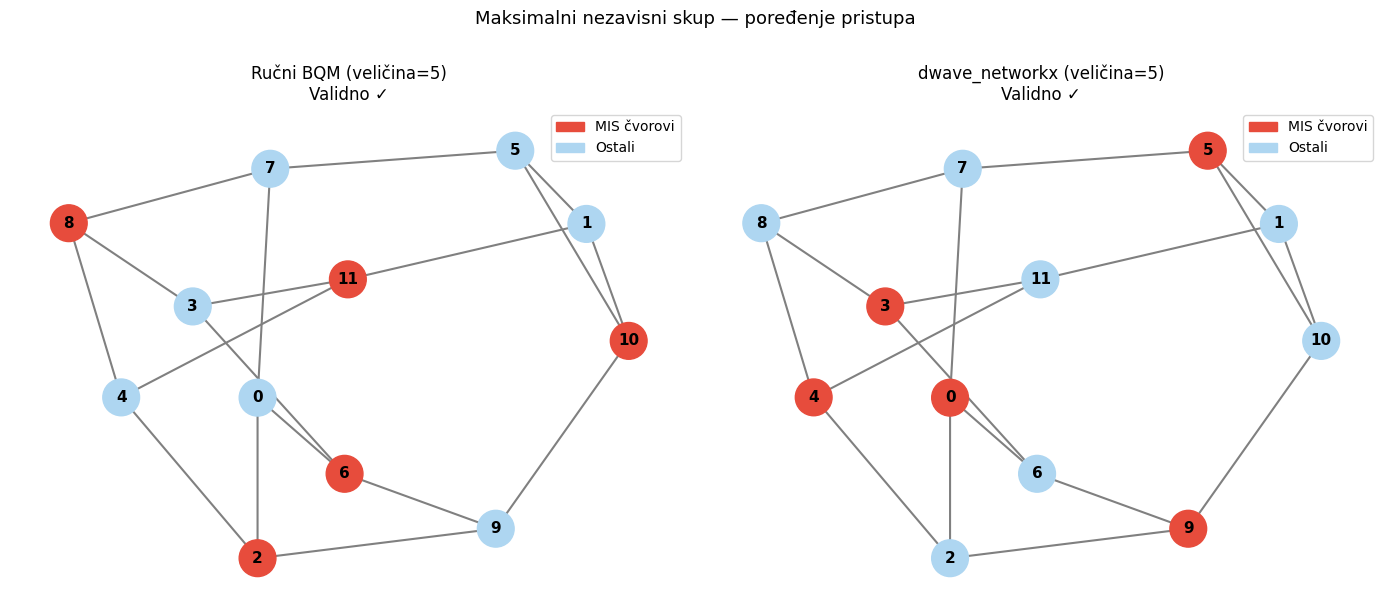

In [8]:
import dimod
import neal
import dwave_networkx as dnx
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- Graf: Slučajni regularni graf ----
np.random.seed(0)
G = nx.random_regular_graph(3, 12, seed=0)  # 12 čvorova, svaki stepen 3
n = G.number_of_nodes()
print(f"Graf: {n} čvorova, {G.number_of_edges()} grana, stepen = 3")

# ---- Pristup A: Ručni BQM ----
P_penalty = 2  # kazna > max korist od jednog čvora (=1)
linear_q = {i: -1 for i in range(n)}
quadratic_q = {(i, j): P_penalty for (i, j) in G.edges()}
bqm_manual = dimod.BinaryQuadraticModel(linear_q, quadratic_q, 0.0, vartype='BINARY')

sa = neal.SimulatedAnnealingSampler()
ss_manual = sa.sample(bqm_manual, num_reads=500, num_sweeps=2000)
best_manual = ss_manual.first
mis_manual  = {v for v, val in best_manual.sample.items() if val == 1}

# ---- Pristup B: dwave_networkx ----
mis_dnx = dnx.maximum_independent_set(G, sampler=sa,
                                       lagrange=P_penalty,
                                       num_reads=500)
mis_dnx = set(mis_dnx)

# ---- Validacija ----
def validate_mis(G, mis):
    return all(not (u in mis and v in mis) for u, v in G.edges())

print(f"\nRučni BQM    → MIS veličina: {len(mis_manual)}, validno: {'DA ✓' if validate_mis(G, mis_manual) else 'NE ✗'}")
print(f"dwave_networkx → MIS veličina: {len(mis_dnx)}, validno: {'DA ✓' if validate_mis(G, mis_dnx) else 'NE ✗'}")
print(f"\nRučni MIS   : {sorted(mis_manual)}")
print(f"dnx MIS     : {sorted(mis_dnx)}")

# ---- Vizualizacija ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pos = nx.spring_layout(G, seed=42)

for ax, mis, title in zip(
    axes,
    [mis_manual, mis_dnx],
    [f'Ručni BQM (veličina={len(mis_manual)})', f'dwave_networkx (veličina={len(mis_dnx)})'],
):
    node_colors = ['#E74C3C' if v in mis else '#AED6F1' for v in range(n)]
    # Naglasimo grane unutar MIS (treba ih biti 0)
    conflict_edges = [(i,j) for i,j in G.edges() if i in mis and j in mis]
    normal_edges   = [(i,j) for i,j in G.edges() if not (i in mis and j in mis)]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges,
                           edge_color='gray', width=1.5, ax=ax)
    if conflict_edges:
        nx.draw_networkx_edges(G, pos, edgelist=conflict_edges,
                               edge_color='red', width=3, ax=ax)
    valid = validate_mis(G, mis)
    ax.set_title(f'{title}\n{"Validno ✓" if valid else "Konflikt ✗"}')
    ax.axis('off')
    p1 = mpatches.Patch(color='#E74C3C', label='MIS čvorovi')
    p2 = mpatches.Patch(color='#AED6F1', label='Ostali')
    ax.legend(handles=[p1, p2], fontsize=10)

plt.suptitle('Maksimalni nezavisni skup — poređenje pristupa', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Kako se koristi stvarni D-Wave hardver

Zamena simulatora za pravi kvantni hardver zahteva samo promenu samplera:

```python
from dwave.system import DWaveSampler, EmbeddingComposite

# EmbeddingComposite automatski mapira logički problem
# na fizičku topologiju D-Wave čipa (Pegasus)
sampler = EmbeddingComposite(DWaveSampler())

ss = sampler.sample(bqm,
                    num_reads=1000,
                    annealing_time=20)   # mikrosekunde
```

### Ugradnja (Embedding)

D-Wave čip ima **ograničenu topologiju** (Pegasus — ~15 veza po qubitu). Logički problem mora biti **ugrađen** u fizičku topologiju:

- Jedna logička promenljiva može zahtevati **više fizičkih qubita** (chain)
- `EmbeddingComposite` ovo radi automatski
- Veći problemi zahtevaju bolju strategiju ugradnje

### Parametri žarenja

| Parametar | Opis | Tipična vrednost |
|---|---|---|
| `num_reads` | Broj ponavljanja žarenja | 100 – 10000 |
| `annealing_time` | Trajanje jednog žarenja (μs) | 20 – 2000 |
| `chain_strength` | Jačina veze u chainu | 1 – 10 × max(\|Q\|) |
| `auto_scale` | Automatsko skaliranje | True |

### D-Wave Leap — Pristup hardveru

```python
# Postavljanje API tokena
# dwave config create  (u terminalu)
# ili environment varijabla:
import os
os.environ['DWAVE_API_TOKEN'] = 'VAŠ_TOKEN'

# Hybrid solver (klasično + kvantno, radi na velikim problemima)
from dwave.system import LeapHybridSampler
hybrid_sampler = LeapHybridSampler()
ss = hybrid_sampler.sample(bqm, time_limit=5)
```

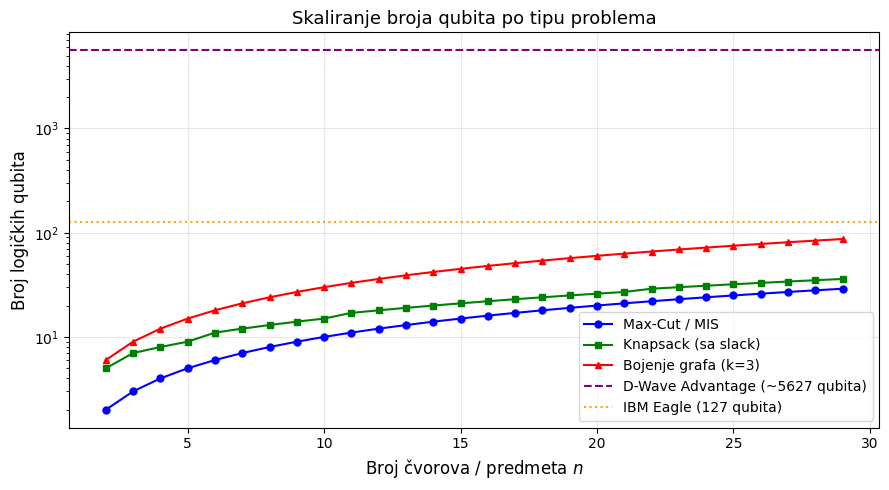

Napomena: fizičkih qubita je potrebno više zbog ugradnje (embedding).
Tipično: 3-5x više fizičkih nego logičkih qubita.


In [9]:
# Simulacija skaliranja: koliko qubita treba za svaki tip problema?
import matplotlib.pyplot as plt
import numpy as np

n_vals = np.arange(2, 30)

# Broj logičkih qubita
max_cut_q   = n_vals                        # 1 qubit po čvoru
mis_q       = n_vals                        # 1 qubit po čvoru
knapsack_q  = n_vals + np.ceil(np.log2(n_vals*3)).astype(int)  # n + slack bita
coloring_q  = n_vals * 3                    # n * k (k=3 boje)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_vals, max_cut_q,  'b-o',  markersize=5, label='Max-Cut / MIS')
ax.plot(n_vals, knapsack_q, 'g-s',  markersize=5, label='Knapsack (sa slack)')
ax.plot(n_vals, coloring_q, 'r-^',  markersize=5, label='Bojenje grafa (k=3)')
ax.axhline(5627, color='purple', linestyle='--', linewidth=1.5,
           label='D-Wave Advantage (~5627 qubita)')
ax.axhline(127, color='orange', linestyle=':', linewidth=1.5,
           label='IBM Eagle (127 qubita)')
ax.set_xlabel('Broj čvorova / predmeta $n$', fontsize=12)
ax.set_ylabel('Broj logičkih qubita', fontsize=12)
ax.set_title('Skaliranje broja qubita po tipu problema', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("Napomena: fizičkih qubita je potrebno više zbog ugradnje (embedding).")
print("Tipično: 3-5x više fizičkih nego logičkih qubita.")

## 5. Rezime — Ocean SDK tok rada

```
1. Definisanje problema
         ↓
2. Gradnja BQM / QUBO
         ↓
3. Izbor samplera
   ┌─────────────────────────────────────────┐
   │ SimulatedAnnealingSampler  ← razvoj/test │
   │ ExactSolver                ← mali problemi│
   │ DWaveSampler               ← kvantni hardver│
   │ LeapHybridSampler          ← veliki problemi│
   └─────────────────────────────────────────┘
         ↓
4. sampler.sample(bqm, num_reads=N)
         ↓
5. Analiza SampleSet-a
   ss.first          → najbolje rešenje
   ss.samples()      → sva rešenja
   ss.record         → numpy structured array
```

### Ključne klase

| Klasa | Paket | Opis |
|---|---|---|
| `BinaryQuadraticModel` | `dimod` | QUBO/Izing model |
| `ConstrainedQuadraticModel` | `dimod` | Model sa eksplicitnim ograničenjima |
| `SampleSet` | `dimod` | Kolekcija rešenja sa energijama |
| `SimulatedAnnealingSampler` | `neal` | Klasični SA solver |
| `DWaveSampler` | `dwave-system` | Kvantni hardver |
| `EmbeddingComposite` | `dwave-system` | Auto-embedding za hardver |

---

> **Sledeće:** QAOA — Aproksimativna kvantna optimizacija na gate-baziranim kvantnim računarima (Qiskit).